In [1]:
from google.colab import files

uploaded = files.upload()

Saving CMAPSSData.zip to CMAPSSData.zip


In [2]:
import zipfile
import os

zip_file = "CMAPSSData.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("NASA_Data")

In [3]:
os.listdir("NASA_Data")

['test_FD004.txt',
 'readme.txt',
 'train_FD001.txt',
 'RUL_FD004.txt',
 'test_FD001.txt',
 'train_FD004.txt',
 'RUL_FD001.txt',
 'Damage Propagation Modeling.pdf',
 'train_FD003.txt',
 'test_FD002.txt',
 'test_FD003.txt',
 'train_FD002.txt',
 'RUL_FD002.txt',
 'RUL_FD003.txt']

In [4]:
import pandas as pd
import numpy as np

In [5]:
columns = [
    "engine_id",
    "cycle",
    "setting1",
    "setting2",
    "setting3"
]

for i in range(1,22):
    columns.append(f"sensor_{i}")

len(columns)

26

In [6]:
train_path = "NASA_Data/train_FD001.txt"

df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)

df.columns = columns

In [7]:
df.head()

,engine_id,cycle,setting1,setting2,setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [8]:
df.shape

(20631, 26)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting1   20631 non-null  float64
 3   setting2   20631 non-null  float64
 4   setting3   20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

In [10]:
df['engine_id'].nunique()

100

In [11]:
max_cycle = df.groupby('engine_id')['cycle'].max()

max_cycle.head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


In [12]:
df['RUL'] = df.apply(
    lambda row:
    max_cycle[row['engine_id']] - row['cycle'],
    axis=1
)

In [13]:
df.head()

,engine_id,cycle,setting1,setting2,setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0


In [14]:
df['failure'] = np.where(
    df['RUL'] <= 30,
    1,
    0
)

0    healthy        
1    failure risk

0    healthy      
1    failure risk

In [15]:
df['failure'].value_counts()

,count
failure,
0,17531
1,3100


Step 5: Data visualization



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

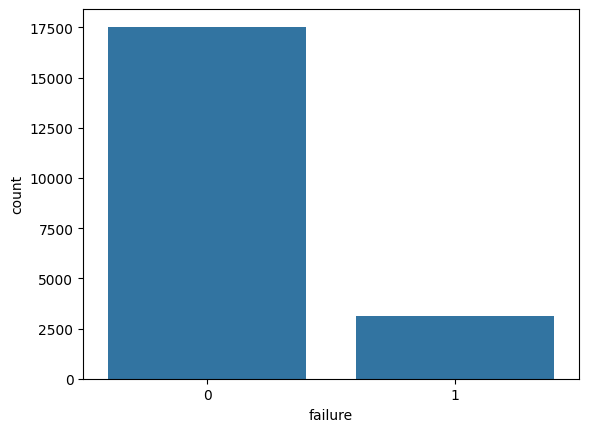

In [17]:
sns.countplot(
    x='failure',
    data=df
)

plt.show()

Sensor behaviour

In [18]:
engine1 = df[df['engine_id']==1]

engine1.head()

,engine_id,cycle,setting1,setting2,setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,failure
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191.0,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190.0,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189.0,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188.0,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187.0,0


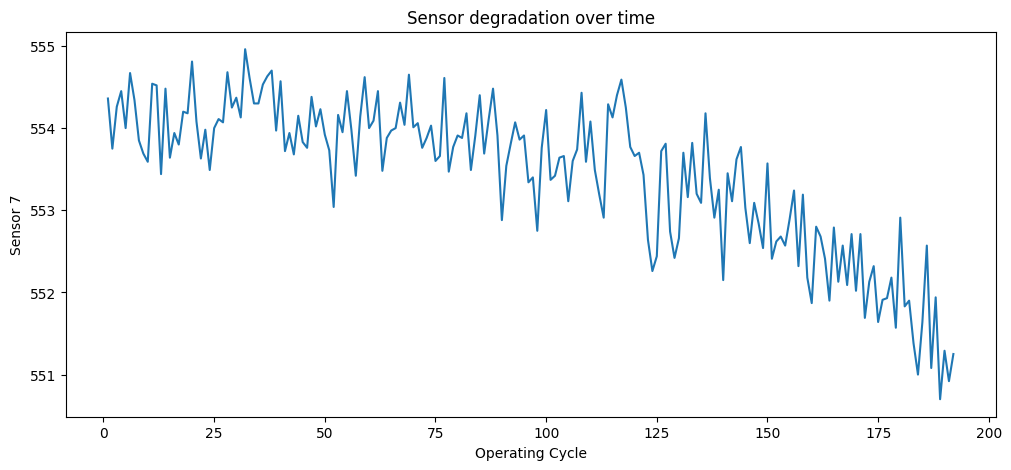

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    engine1['cycle'],
    engine1['sensor_7']
)

plt.xlabel("Operating Cycle")
plt.ylabel("Sensor 7")

plt.title("Sensor degradation over time")

plt.show()

In [20]:
corr = df.corr()

corr['failure'].sort_values()

,failure
sensor_12,-0.640174
sensor_7,-0.625592
sensor_21,-0.606480
sensor_20,-0.599912
RUL,-0.566596
engine_id,-0.014482
setting2,0.009402
setting1,0.010499
sensor_6,0.059579
sensor_14,0.341063


In [21]:
df.nunique()

,0
engine_id,100
cycle,362
setting1,158
setting2,13
setting3,1
sensor_1,1
sensor_2,310
sensor_3,3012
sensor_4,4051
sensor_5,1


In [22]:
drop_cols = [
    'setting3',
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]


df = df.drop(
    drop_cols,
    axis=1
)

In [23]:
df.shape

(20631, 21)

In [24]:
df.head()

,engine_id,cycle,setting1,setting2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,failure
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191.0,0
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190.0,0
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189.0,0
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188.0,0
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187.0,0


In [25]:
X = df.drop(
    ['failure','RUL'],
    axis=1
)

y = df['failure']

In [26]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
X_train.shape, X_test.shape

((16504, 19), (4127, 19))

Model import

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

Training

In [30]:
model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [31]:
y_pred = model.predict(
    X_test
)

In [32]:
y_pred



array([1, 0, 0, ..., 1, 0, 0])

In [33]:
from sklearn.metrics import classification_report


print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3507
           1       0.91      0.86      0.88       620

    accuracy                           0.97      4127
   macro avg       0.94      0.92      0.93      4127
weighted avg       0.96      0.97      0.96      4127



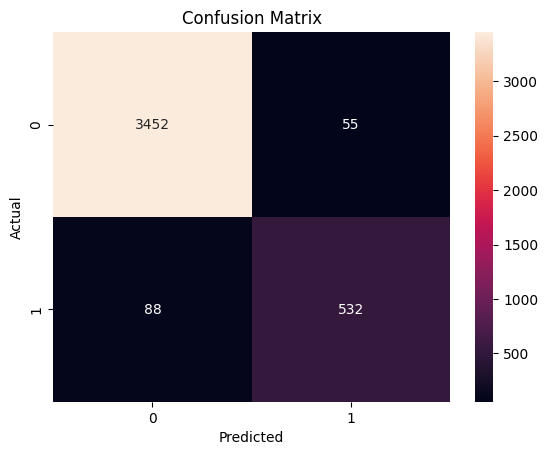

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [35]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
11,sensor_11,0.186724
6,sensor_4,0.178870
12,sensor_12,0.108583
8,sensor_7,0.103910
15,sensor_15,0.086098
17,sensor_20,0.049630
18,sensor_21,0.046372
1,cycle,0.040983
10,sensor_9,0.036838
14,sensor_14,0.033819


In [36]:
!pip install xgboost

In [37]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42,

    scale_pos_weight=5

)

In [38]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [39]:
xgb_pred = xgb_model.predict(
    X_test
)

In [40]:
from sklearn.metrics import classification_report


print(
classification_report(
    y_test,
    xgb_pred
)
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3507
           1       0.86      0.95      0.90       620

    accuracy                           0.97      4127
   macro avg       0.92      0.96      0.94      4127
weighted avg       0.97      0.97      0.97      4127



In [41]:
importance_xgb = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})


importance_xgb.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
11,sensor_11,0.568805
6,sensor_4,0.095817
12,sensor_12,0.055607
10,sensor_9,0.053592
16,sensor_17,0.031203
15,sensor_15,0.027513
8,sensor_7,0.026767
1,cycle,0.022201
14,sensor_14,0.018702
13,sensor_13,0.015985


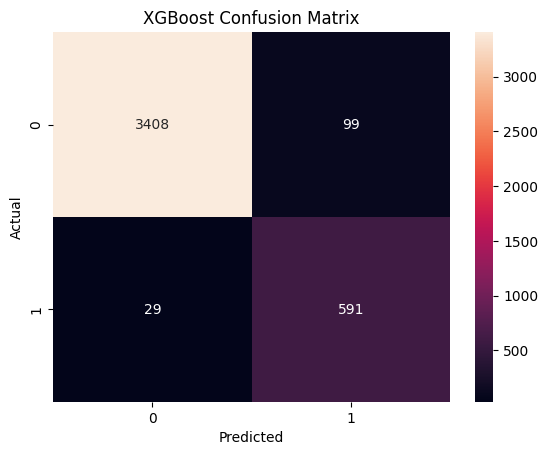

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    xgb_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [43]:
import joblib


joblib.dump(
    xgb_model,
    "failure_prediction_model.pkl"
)

['failure_prediction_model.pkl']

In [44]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=950916cd6952e868a331c5944d97113ea658e42158341e7afcb5ec876fca6c5b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [45]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [46]:
kmf = KaplanMeierFitter()

In [47]:
kmf.fit(
    durations=df['cycle'],
    event_observed=df['failure']
)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 20631 total observations, 17531 right-censored observations>

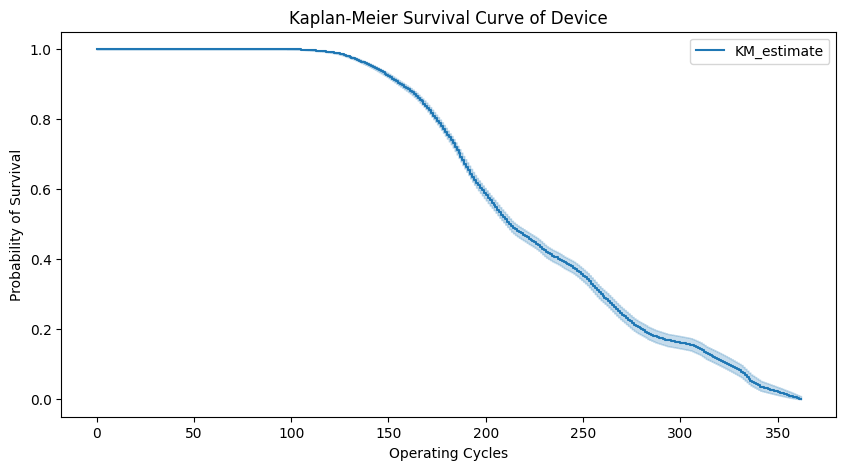

In [48]:
plt.figure(figsize=(10,5))

kmf.plot_survival_function()

plt.title(
    "Kaplan-Meier Survival Curve of Device"
)

plt.xlabel(
    "Operating Cycles"
)

plt.ylabel(
    "Probability of Survival"
)

plt.show()

In [49]:
kmf.median_survival_time_

np.float64(213.0)

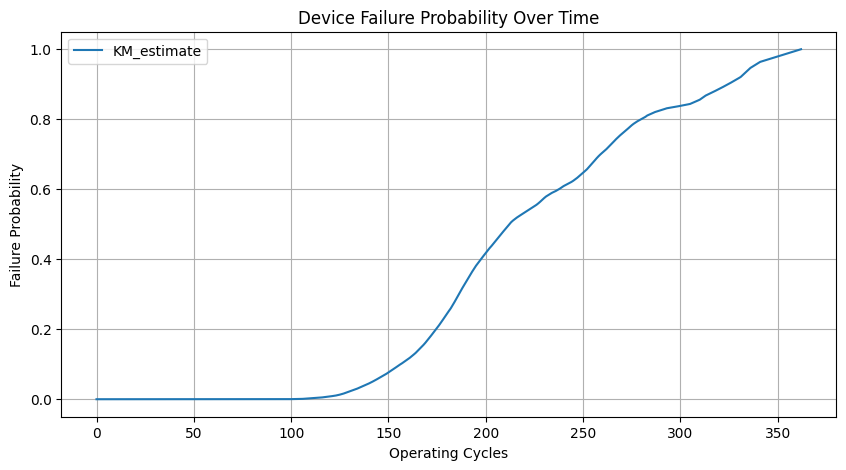

In [50]:
# Failure probability

survival_curve = kmf.survival_function_

failure_probability = 1 - survival_curve


failure_probability.plot(
    figsize=(10,5)
)

plt.title(
    "Device Failure Probability Over Time"
)

plt.xlabel(
    "Operating Cycles"
)

plt.ylabel(
    "Failure Probability"
)

plt.grid()

plt.show()

In [51]:
import joblib

joblib.dump(
    xgb_model,
    "failure_prediction_model.pkl"
)

['failure_prediction_model.pkl']

In [52]:
importance_xgb.to_csv(
    "feature_importance.csv",

    index=False
)

In [53]:
import pickle

with open("kmf_model.pkl","wb") as f:
    pickle.dump(kmf,f)

In [54]:
!ls

CMAPSSData.zip		      feature_importance.csv  NASA_Data
failure_prediction_model.pkl  kmf_model.pkl	      sample_data


In [55]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 125.6 MB/s eta 0:00:00


In [56]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import pickle
import matplotlib.pyplot as plt


# Load trained XGBoost model
model = joblib.load(
    "failure_prediction_model.pkl"
)


# Load feature importance
importance = pd.read_csv(
    "feature_importance.csv"
)


# Load Kaplan-Meier model
with open("kmf_model.pkl","rb") as f:
    kmf = pickle.load(f)



st.title(
    "Predictive Maintenance System for Medical Equipment"
)


st.write(
    "Sensor based failure prediction using Machine Learning and Survival Analysis"
)



st.sidebar.header(
    "Device Sensor Input"
)


features = [
"engine_id",
"cycle",
"setting1",
"setting2",
"sensor_2",
"sensor_3",
"sensor_4",
"sensor_6",
"sensor_7",
"sensor_8",
"sensor_9",
"sensor_11",
"sensor_12",
"sensor_13",
"sensor_14",
"sensor_15",
"sensor_17",
"sensor_20",
"sensor_21"
]


input_data={}


for feature in features:

    input_data[feature] = st.sidebar.number_input(
        feature,
        value=0.0
    )


input_df = pd.DataFrame(
    [input_data]
)



if st.button("Predict Failure"):


    prediction = model.predict(
        input_df
    )


    probability = model.predict_proba(
        input_df
    )[0][1]


    st.metric(
        "Failure Probability",
        f"{probability*100:.2f}%"
    )


    if prediction[0]==1:

        st.error(
            "⚠ High Failure Risk"
        )

    else:

        st.success(
            "Device Healthy"
        )



st.subheader(
    "Important Failure Sensors"
)


st.dataframe(
    importance.sort_values(
        "Importance",
        ascending=False
    ).head(10)
)



st.subheader(
    "Kaplan-Meier Survival Curve"
)


fig,ax = plt.subplots()


kmf.plot_survival_function(
    ax=ax
)


st.pyplot(fig)

Writing app.py


In [57]:
!ls

app.py		failure_prediction_model.pkl  kmf_model.pkl  sample_data
CMAPSSData.zip	feature_importance.csv	      NASA_Data


In [58]:
!pip install pyngrok -q

In [59]:
from google.colab import files

files.download("failure_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
files.download("kmf_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>